# Fase 2 — Análisis Exploratorio de Datos (EDA)
**Grupo 3 · Evento Evaluativo 2 · Análisis de Datos**
Dataset seleccionado: **Titanic** (ver justificación en `01_exploracion_datasets.ipynb`).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (8, 4)
sns.set_style('whitegrid')

titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2.1 Revisión de valores faltantes

In [2]:
missing = titanic.isnull().sum()
missing_pct = (missing / len(titanic) * 100).round(1)
missing_table = pd.DataFrame({'faltantes': missing, 'porcentaje': missing_pct})
missing_table = missing_table[missing_table['faltantes'] > 0].sort_values('porcentaje', ascending=False)
missing_table

,faltantes,porcentaje
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


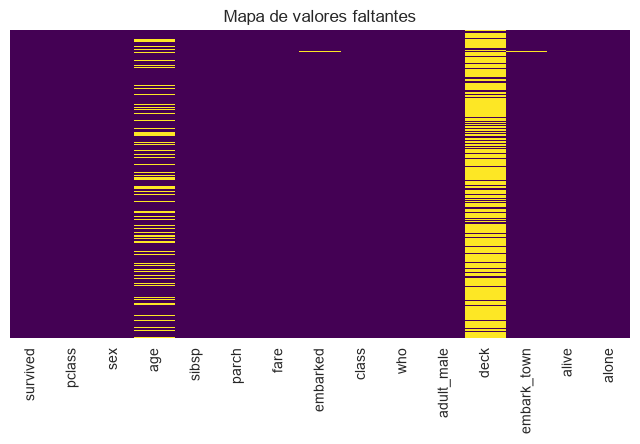

In [3]:
plt.figure(figsize=(8, 4))
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de valores faltantes')
plt.show()

**Interpretación y estrategia de tratamiento:**
- `deck` falta en ~77% de los registros: es demasiado para imputar de forma confiable. Estrategia: **eliminar la columna** (o, alternativamente, crear un indicador binario `tiene_deck_registrado`).
- `age` falta en ~20% de los registros: suficiente información para imputar. Estrategia: **imputar con la mediana** (más robusta que la media frente a los valores atípicos que veremos en 2.2), y opcionalmente crear un indicador `age_imputada` para no perder la señal de que el dato era desconocido.
- `embarked`/`embark_town` falta en solo 2 registros (~0.2%): Estrategia: **imputar con la moda** (el puerto más frecuente) o eliminar esas 2 filas sin impacto relevante.

## 2.2 Detección de valores atípicos

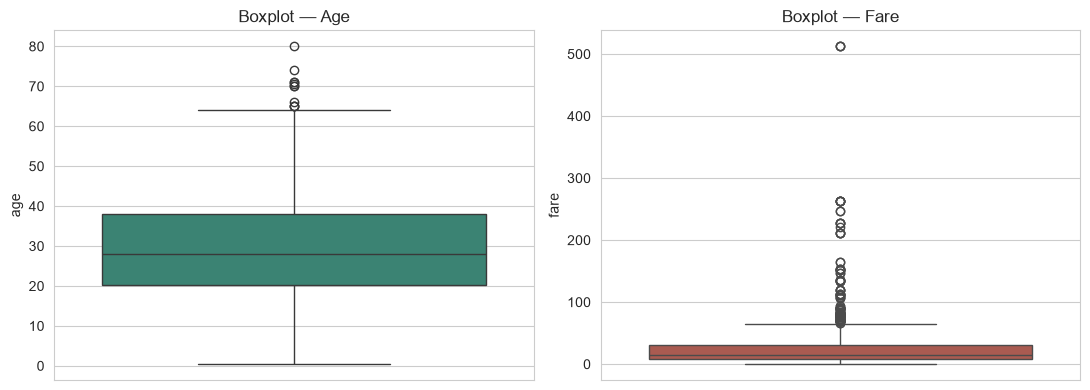

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=titanic['age'], ax=axes[0], color='#2F8F7A')
axes[0].set_title('Boxplot — Age')
sns.boxplot(y=titanic['fare'], ax=axes[1], color='#B85042')
axes[1].set_title('Boxplot — Fare')
plt.tight_layout()
plt.show()

In [5]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return series[(series < lower) | (series > upper)], lower, upper

for col in ['age', 'fare']:
    out, low, high = iqr_outliers(titanic[col].dropna())
    z = np.abs(stats.zscore(titanic[col].dropna()))
    print(f"--- {col} ---")
    print(f"Rango IQR normal: [{low:.1f}, {high:.1f}]  ->  {len(out)} valores atípicos ({len(out)/titanic[col].notna().sum()*100:.1f}%)")
    print(f"Valores con |z-score| > 3: {(z > 3).sum()}")
    print()

--- age ---
Rango IQR normal: [-6.7, 64.8]  ->  11 valores atípicos (1.5%)
Valores con |z-score| > 3: 2

--- fare ---
Rango IQR normal: [-26.7, 65.6]  ->  116 valores atípicos (13.0%)
Valores con |z-score| > 3: 20



**Discusión:** `fare` tiene una cola larga de valores altos (pasajes de primera clase muy costosos) — son atípicos estadísticamente, pero representan pasajeros reales de alto poder adquisitivo, no errores de captura, así que **se conservan** (podrían transformarse con logaritmo más adelante si afectan un modelo). `age` tiene pocos atípicos (personas muy mayores), también plausibles y se conservan.